In [1]:
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
import HolograPy as hp

In [2]:
def batch_propagate(f_points, board_points_list, board_norms_list, e_points, e_nx, e_ny, k):
    P_focus = np.ones(len(f_points))*np.exp(1j*np.ones(len(f_points)))
    P_board_eval_list = []
    for i, board_points in enumerate(board_points_list):
        H_board_focus = hp.PM_forward_model(np.array(f_points), board_points, board_norms_list[i], k)
        P_board = P_focus @ np.conj(H_board_focus)
        H_board_eval = hp.PM_forward_model(e_points, board_points, board_norms_list[i], k)
        P_board_eval = (H_board_eval @ P_board).reshape(e_nx, e_ny)
        P_board_eval_list.append(P_board_eval)
    return P_board_eval_list

In [3]:
# physics params
c0 = 343.  # [m/s]
f = 40000
lam = c0/f
k = 2*np.pi/lam

In [4]:
# create a board with its centre at the origin, normal vector pointing upwards (+z)
t1_v1, t1_v2 = [1,0,0], [0,1,0]
t1_spacingx, t1_spacingy = 10.5/1000, 10.5/1000
t1_nx, t1_ny = 16, 16
t1_radius = 4.5/1000
t1_origin = [t1_spacingx/2 -t1_spacingx * t1_nx/2,
            t1_spacingy/2 -t1_spacingy * t1_ny/2,
            0]
t1_normal = [0, 0, 1]
t1_points = hp.compute_grid_2d(t1_origin, t1_v1, t1_v2, t1_spacingx, t1_spacingy, t1_nx, t1_ny)

In [5]:
# create a board with its centre at the origin, normal vector pointing upwards (+z)
t2_v1, t2_v2 = [1,0,0], [0,1,0]
t2_spacingx, t2_spacingy = 10.5/1000, 10.5/1000
t2_nx, t2_ny = 16, 16
t2_radius = 4.5/1000
t2_origin = [t2_spacingx/2 -t2_spacingx * t2_nx/2,
            t2_spacingy/2 -t2_spacingy * t2_ny/2,
            240/1000]
t2_normal = [0, 0, -11]
t2_points = hp.compute_grid_2d(t2_origin, t2_v1, t2_v2, t2_spacingx, t2_spacingy, t2_nx, t2_ny)

In [6]:
# # Defining an evaluation plane
# e_v1, e_v2 = [1,0,0], [0,0,1]
# e_spacingx, e_spacingz = 1/1000, 1/1000
# e_nx, e_nz = 240, 168
# e_origin = [-.084,
#             0,
#             0]

# e_points = hp.compute_grid_2d(e_origin, e_v1, e_v2, e_spacingx, e_spacingz, e_nx, e_nz)

In [10]:
# Defining an evaluation plane
e_v1, e_v2 = [1,0,0], [0,0,1]
e_spacingx, e_spacingz = 2/1000, 2/1000
e_nx, e_nz = 120, 500
e_origin = [-.5,
            0,
            0]

e_points = hp.compute_grid_2d(e_origin, e_v1, e_v2, e_spacingx, e_spacingz, e_nx, e_nz)
print(e_points.shape)

(60000, 3)


In [11]:
# lets define our focal point(s)
f_points = [[0, 0, 120/1000]]

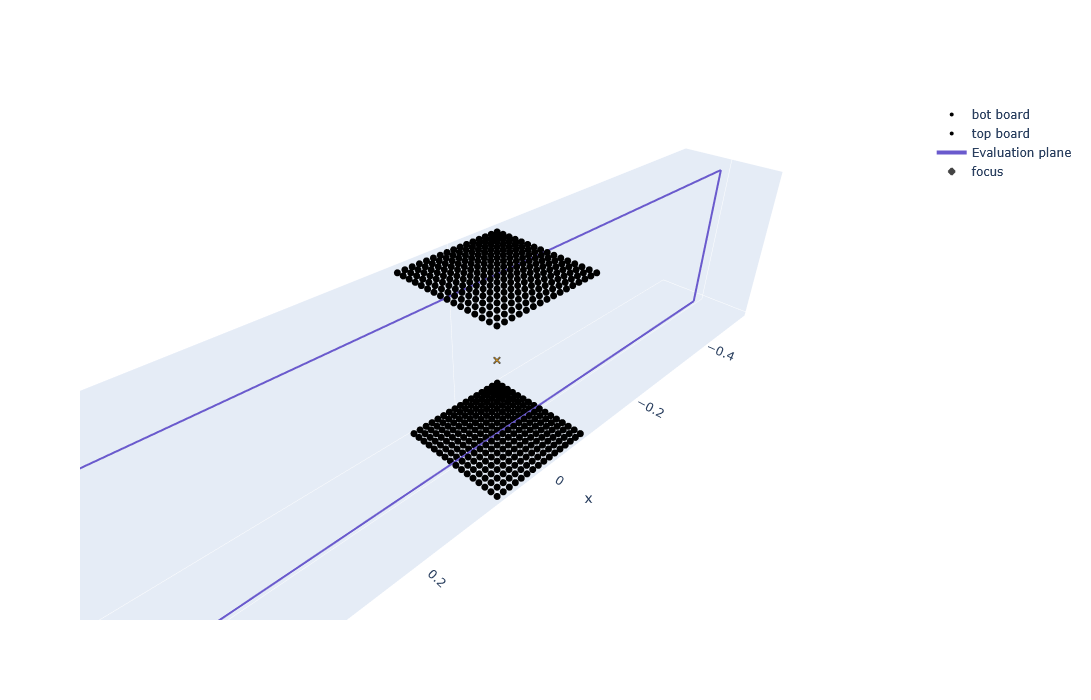

In [13]:
fig = go.Figure()

hp.plot_plane_points_plotly(fig, t1_points, color='black', label="bot board")
hp.plot_plane_points_plotly(fig, t2_points, color='black', label="top board")
hp.plot_plane_edges_plotly(fig, e_points, n_cols=500, color='slateblue', label="Evaluation plane")

fig.add_trace(go.Scatter3d(x=[f_points[0][0]],
                           y=[f_points[0][1]],
                           z=[f_points[0][2]],
                           mode='markers',
                           name='focus',
                           marker=dict(symbol='x',
                                       size=2,
                                       color='orange',
                                       line=dict(width=4))))
fig.update_layout(
    scene=dict(
        xaxis=dict(showgrid=False),
        yaxis=dict(showgrid=False),
        zaxis=dict(showgrid=False),
        aspectmode='data'  # equal scaling for all axes
    ),
    width=700,
    height=700,
    showlegend=True
)

fig.show()

In [14]:
# now we find forward models for each board and the focus
H_t1_focus = hp.PM_forward_model(np.array(f_points), t1_points, t1_normal, k)
H_t2_focus = hp.PM_forward_model(np.array(f_points), t2_points, t2_normal, k)

In [15]:
# we set the pressure at the focus
print(len(f_points))
P_focus = np.ones(len(f_points))*np.exp(1j*np.ones(len(f_points)))

# now we find the pressure activations for each of the boards
P_t1 = P_focus @ np.conj(H_t1_focus)
P_t2 = P_focus @ np.conj(H_t2_focus)

# REMEMBER TO CONSTRAIN THE AMPLITUDES BACK DOWN TO 1
P_t1 = np.ones_like(P_t1)*np.exp(1j*np.angle(P_t1))
P_t2 = np.ones_like(P_t2)*np.exp(1j*np.angle(P_t2))

1


In [16]:
# now we find forward models for each board and the evaluation plane
H_t1_eval = hp.PM_forward_model(e_points, t1_points, t1_normal, k)
H_t2_eval = hp.PM_forward_model(e_points, t2_points, t2_normal, k)

In [17]:
# Propagate from boards to evaluation plane
P_t1_eval = (H_t1_eval @ P_t1).reshape(e_nx, e_nz)
P_t2_eval = (H_t2_eval @ P_t2).reshape(e_nx, e_nz)

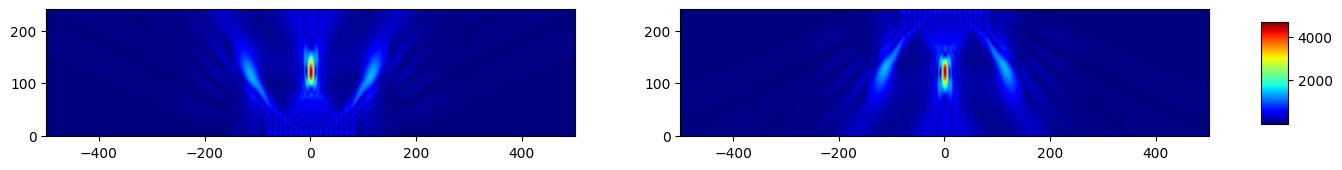

In [23]:
# Plotting

ex = [-500, 500, 0, 240]

fix, ax = plt.subplots(1, 2, figsize=(15, 5))

im0 = ax.flat[0].imshow(abs(P_t1_eval), cmap=plt.get_cmap('jet'), origin='lower', extent=ex)
im1 = ax.flat[1].imshow(abs(P_t2_eval), cmap=plt.get_cmap('jet'), origin='lower', extent=ex)

cax = ax.flat[1].inset_axes([1.1, .1, 0.05, 0.8]) # [x0, y0, width, height]
plt.colorbar(im1, cax=cax)

plt.show()

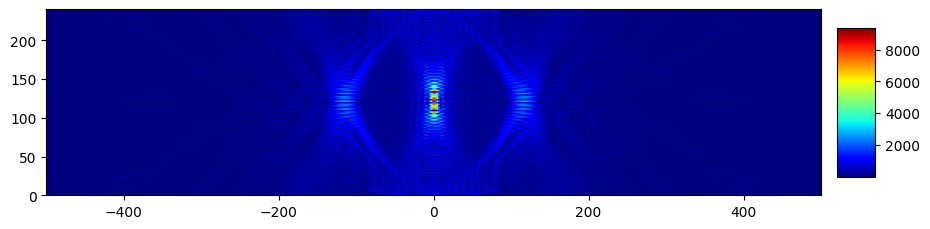

In [41]:
# Plot the summed field
P_summed_eval = P_t1_eval + P_t2_eval

fig, ax = plt.subplots(figsize=(10,5))

im0 = ax.imshow(abs(P_summed_eval), cmap=plt.get_cmap('jet'), origin='lower', extent=ex)
cax = ax.inset_axes([1.02, .1, 0.05, 0.8]) # [x0, y0, width, height]
plt.colorbar(im0, cax=cax)

plt.show()

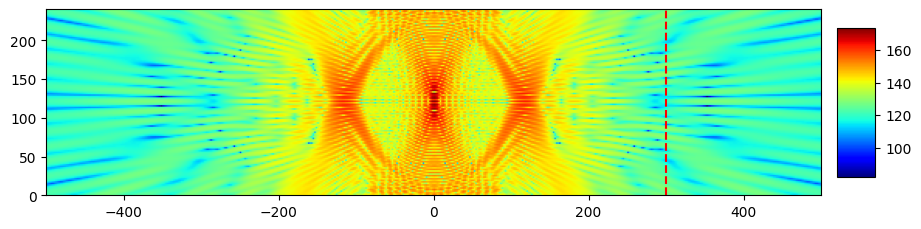

In [47]:
SPL = 20 * np.log10(np.maximum(np.abs(abs(P_summed_eval)), 1e-12) / 20e-6)

fig, ax = plt.subplots(figsize=(10,5))
im1 = ax.imshow(SPL, cmap=plt.get_cmap('jet'), origin='lower', extent=ex)
cax = ax.inset_axes([1.02, .1, 0.05, 0.8]) # [x0, y0, width, height]
ax.vlines(300, 0, 240, color='red', ls='--')
plt.colorbar(im1, cax=cax)
plt.show()

(120, 500)
122.17169019343164


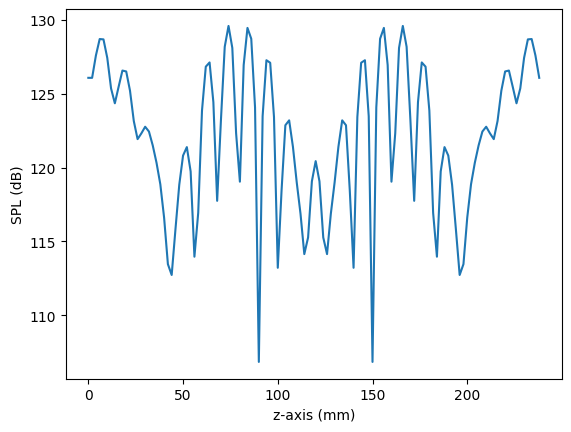

In [56]:
print(SPL.shape)

z_cutline = SPL[:,400]
print(np.mean(z_cutline))

plt.plot(np.arange(0,240,2), z_cutline)
plt.xlabel('z-axis (mm)')
plt.ylabel('SPL (dB)')
plt.show()